# Julia notebook to experiment with Peterson & Callies (2025, in review) theory.

twnh Sep '23

This notebook solves the steady frictional thermal wind equations with a Green's function.

The problem is to solve:

\begin{align}
- f \frac{\partial v}{\partial z} & = - \frac{\partial b}{\partial x} + \epsilon^2  \frac{\partial }{\partial z} \left( \nu \frac{\partial u}{\partial z} \right), \\
  f \frac{\partial u}{\partial z} & = - \frac{\partial b}{\partial y} + \epsilon^2  \frac{\partial }{\partial z} \left( \nu \frac{\partial v}{\partial z} \right) , 
\end{align}
for $u(z), v(z)$, given forcing function $b(x,y,z)$, viscosity $\nu(z)$, and boundary conditions
\begin{align}
\text{Surface~}z = 0:
\begin{cases}
\displaystyle \epsilon^2 \nu \partial_z u & = \tau^x \\
\displaystyle  \epsilon^2 \nu \partial_z v & = \tau^y 
\end{cases}
 \\
\text{Bottom~}z = -H:
\begin{cases}
u & = 0  \\
v & = 0 
\end{cases} ,
\end{align}
where $(\tau^x, \tau^y)$ is the known wind stress.

Write a single equation in $\frak{u} = u + i v$:

\begin{align}
f \frac{\partial \frak{u} }{\partial z} + i \epsilon^2  \frac{\partial }{\partial z} \left(\nu \frac{\partial \frak{u} }{\partial z} \right) & = - \frac{\partial b}{\partial y} + i \frac{\partial b}{\partial x} , \\
\text{Surface~}z = 0:
\epsilon^2 \nu \partial_z \frak{u} & = \tau^x + i \tau^y,  \\
\text{Bottom~}z = -H:
\frak{u} & = 0 .
\end{align}

### Approach: Solve the Green's function problem first:

\begin{align}
f \frac{\partial \frak{G} }{\partial z} + i \epsilon^2  \frac{\partial}{\partial z} \left( \nu \frac{\partial \frak{G} }{\partial z} \right) & = \delta(z - \xi) ,
\end{align}

for $\frak{G}(z; \xi)$ with boundary conditions
\begin{align}
\text{Surface~}z = 0:
\epsilon^2 \nu \partial_z \frak{G} & = 0,  \\
\text{Bottom~}z = -H:
\frak{G} & = 0 .
\end{align}

### Solution:

Construct $\frak{G} (z; \xi)$ either side of the point $\xi$:

1. Solve for $\frak{G}_- (z)$ on $-H \le z \le \xi$.
2. Solve for $\frak{G} _+ (z)$ on $\xi \le z \le 0$.

3. Compute the Wronskian of $\frak{G} _-(z)$ and $\frak{G} _+(z)$:

4. Write the Green's function as

\begin{align}
\frak{G} (z; \xi) = \begin{cases}
\displaystyle \frac{\frak{G} _-(z) \frak{G} _+(\xi)}{  W(\xi)} &\text{\normalsize~~for~} -H \le z \le \xi \\
\displaystyle \frac{\frak{G} _+(z) \frak{G} _-(\xi)}{  W(\xi)} &\text{\normalsize~~for~} \xi \le z \le 0 
\end{cases} .
\end{align}

5. Solve the original problem using $\frak{G} (z; \xi)$:

\begin{equation}
\frak{u}(z) = \int_{-H}^{0} \frak{G} (z; \xi) \left( - \frac{\partial b}{\partial y} +  i \frac{\partial b}{\partial x} \right) \; d \xi .
\end{equation}

In [1]:
using SymPy

Define symbols and functions

In [2]:
f, ϵ, ν₀, H, α = symbols("f ϵ ν₀ H α", real=true, positive=true)
τˣ, τʸ         = symbols("τˣ τʸ",      real=true)
z, ξ, A        = symbols("z ξ A",      real=true)
# 𝔲              = symbols("𝔲", cls=SymFunction, complex=true)
𝔲 = SymFunction("𝔲")           # <-- no call here, creates function *object* u(z)


# Define viscosity profile here:
# ν = ν₀                             # Constant viscosity profile
# ν = ν₀ + exp(-α*(z+H))             # Bottom-intensified viscosity profile
# ν = ν₀ + exp(α*z)                  # Surface-intensified viscosity profile
ν = ν₀ + exp(α*z) + exp(-α*(z+H))   # Bottom and surface-intensified viscosity profile. THIS CAUSES ISSUES WITH SYMPY
nothing

Define the ODE:

In [3]:
ode = Eq(f * diff(𝔲(z),z) + ϵ^2 * im * diff(ν * diff(𝔲(z),z),z), A)

                  /                                                            >
  d             2 |/   z*α      -α*(H + z)\ d          /      z*α    -α*(H + z >
f*--(𝔲(z)) + I*ϵ *|\α*e    - α*e          /*--(𝔲(z)) + \ν₀ + e    + e          >
  dz              |                         dz                                 >
                  \                                                            >

>     2       \    
> )\ d        |    
>  /*---(𝔲(z))| = A
>      2      |    
>    dz       /    

1. Solve for $\frak{G}_- (z)$ on $-H \le z \le \xi$:

In [4]:
println(𝔲(z))
println(typeof(𝔲(z)))
println(ode)
println(typeof(z))
println(typeof(H))

𝔲(z)
Sym{PyCall.PyObject}
Eq(f*Derivative(𝔲(z), z) + I*ϵ^2*((α*exp(z*α) - α*exp(-α*(H + z)))*Derivative(𝔲(z), z) + (ν₀ + exp(z*α) + exp(-α*(H + z)))*Derivative(𝔲(z), (z, 2))), A)
Sym{PyCall.PyObject}
Sym{PyCall.PyObject}


In [5]:
𝔊ₘ = dsolve(ode.subs(A,0), 𝔲(z), ics = Dict(𝔲(-H)=>0)).rhs
@assert simplify(𝔊ₘ.subs(z,-H)) == 0  # Check bottom BC
display(𝔊ₘ)

PyCall.PyError: PyError ($(Expr(:escape, :(ccall(#= /Users/twnh/.julia/packages/PyCall/1gn3u/src/pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'ValueError'>
ValueError('expected a univariate function, got _x7')
  File "/Users/twnh/.julia/conda/3/aarch64/lib/python3.10/site-packages/sympy/solvers/ode/ode.py", line 640, in dsolve
    return _helper_simplify(eq, hint, hints, simplify, ics=ics)
  File "/Users/twnh/.julia/conda/3/aarch64/lib/python3.10/site-packages/sympy/solvers/ode/ode.py", line 670, in _helper_simplify
    sols = solvefunc.get_general_solution()
  File "/Users/twnh/.julia/conda/3/aarch64/lib/python3.10/site-packages/sympy/solvers/ode/single.py", line 283, in get_general_solution
    return self._get_general_solution(simplify_flag=simplify)
  File "/Users/twnh/.julia/conda/3/aarch64/lib/python3.10/site-packages/sympy/solvers/ode/single.py", line 897, in _get_general_solution
    sol = dsolve(eq, func(x))
  File "/User

2. Solve for $\frak{G}_+ (z)$ on $\xi \le z \le 0$

In [6]:
𝔊ₚ = dsolve(ode.subs(A,0), 𝔲(z), ics = Dict(diff(𝔲(z),z).subs(z,0)=>0)).rhs
@assert simplify(diff(𝔊ₚ,z).subs(z,0)) == 0  # Check surface BC
display(𝔊ₚ)

PyCall.PyError: PyError ($(Expr(:escape, :(ccall(#= /Users/twnh/.julia/packages/PyCall/1gn3u/src/pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'ValueError'>
ValueError('expected a univariate function, got _x7')
  File "/Users/twnh/.julia/conda/3/aarch64/lib/python3.10/site-packages/sympy/solvers/ode/ode.py", line 640, in dsolve
    return _helper_simplify(eq, hint, hints, simplify, ics=ics)
  File "/Users/twnh/.julia/conda/3/aarch64/lib/python3.10/site-packages/sympy/solvers/ode/ode.py", line 670, in _helper_simplify
    sols = solvefunc.get_general_solution()
  File "/Users/twnh/.julia/conda/3/aarch64/lib/python3.10/site-packages/sympy/solvers/ode/single.py", line 283, in get_general_solution
    return self._get_general_solution(simplify_flag=simplify)
  File "/Users/twnh/.julia/conda/3/aarch64/lib/python3.10/site-packages/sympy/solvers/ode/single.py", line 897, in _get_general_solution
    sol = dsolve(eq, func(x))
  File "/User

3. Compute Wronskian $W(z)$:

In [7]:
W = simplify(𝔊ₘ * diff(𝔊ₚ, z) - 𝔊ₚ * diff(𝔊ₘ, z))

UndefVarError: UndefVarError: `𝔊ₘ` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

4. Compute Green's function $\frak{G}(z; \xi)$:

In [8]:
Gm = simplify(𝔊ₘ * 𝔊ₚ.subs(z,ξ) / (W.subs(z,ξ)))
Gp = simplify(𝔊ₘ.subs(z,ξ) * 𝔊ₚ / (W.subs(z,ξ)))

# Check continuity and jump condition:
@assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
@assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1 == 0

# Define piecewise Green's function:
G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))
display(G)

# Check boundary conditions:
# @assert simplify(G.subs([(z,-H),(ξ,-H/2)])) == 0          # This doesn't work for complex ν(z). It overwhelms simplify I think.
@assert simplify(G.subs([(z,-H),(ξ,-H/2)]).subs(H,1).subs(ϵ,5).subs(α,4).subs(ν₀,2).subs(f,3)) == 0     # But this works.
@assert simplify(diff(G,z).subs(z,0).subs(ξ,-H/2)) == 0

UndefVarError: UndefVarError: `𝔊ₘ` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Make plot of Green's function for sample parameters

In [9]:
using Plots

# Pick the value of ξ in [-H, 0]:
ξᵢ     = -0.5
f_val  = 1.0
α_val  = 32.0
ϵ_val  = 1.0
H_val  = 1.0
ν₀_val = 0.125
# Insert parameter values here and convert symbolic G to a function:
G_fixed(zᵢ,ξᵢ)  = G.subs([(f, f_val), (ν₀, ν₀_val), (α, α_val), (ϵ, ϵ_val), (H, H_val), (ξ, ξᵢ), (z, zᵢ)])

# --- Plot ---
zvals = range(-1, 0, length=512)
Gvals = [G_fixed(z_, ξᵢ) |> complex for z_ in zvals]  # use complex() to get a number
plot( real(Gvals), zvals, label="u", ylabel="z", xlabel="G(z, ξ = $ξᵢ)", title="Green's Function for ξ = $ξᵢ", legend=false)
plot!(imag(Gvals), zvals, label="v", legend=true)
hline!([ξᵢ], label="ξ", linestyle=:dash, color=:red)

UndefVarError: UndefVarError: `G` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

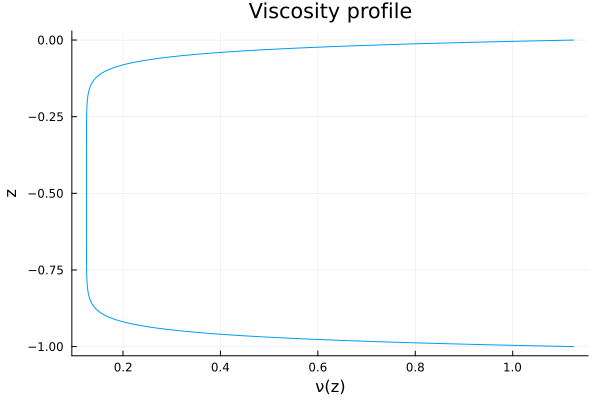

In [10]:
ν_fixed(zᵢ) = ν.subs([(ν₀, ν₀_val), (α, α_val), (H, H_val), (z, zᵢ)])
νvals = [ν_fixed(z_) |> float for z_ in zvals]
plot( νvals, zvals, label="ν(z)", ylabel="z", xlabel="ν(z)", title="Viscosity profile", legend=false)